# Листок №1. СЛАУ, матрицы, квадратичные формы

Полное решение всех задач листка с использованием Python (`numpy`, `scipy`, `sympy`, `matplotlib`).

In [47]:
import numpy as np
import scipy.linalg as la
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from sympy import *
init_printing()

## Задача 1.1

Найти общее решение системы линейных уравнений

$$\begin{cases} x_1+5x_2-2x_3=-7,\\ -3x_1+x_2+9x_3-5x_4=9,\\ 4x_1-8x_2-x_3+7x_4=0.\end{cases}$$

In [48]:
A = np.array([[1,5,-2,0],[-3,1,9,-5],[4,-8,-1,7]])
b = np.array([-7,9,0]).reshape(3,1)
A_b = np.hstack([A,b])
rref, pivots = Matrix(A_b).rref()
rref, pivots

⎛⎡1  0  0  8/7   -11/7⎤           ⎞
⎜⎢                    ⎥           ⎟
⎜⎢0  1  0  -2/7  -6/7 ⎥, (0, 1, 2)⎟
⎜⎢                    ⎥           ⎟
⎝⎣0  0  1  -1/7   4/7 ⎦           ⎠

Из rref расширенной матрицы: базисные переменные $x_1,x_2,x_3$, свободная переменная $x_4=t$.

$$x_1=-\tfrac{11}{7}-\tfrac{8}{7}t,\quad x_2=-\tfrac{6}{7}+\tfrac{2}{7}t,\quad x_3=\tfrac{4}{7}+\tfrac{1}{7}t,\quad x_4=t.$$

In [49]:
t = symbols('t')
x1 = rref[0,3]*(-t) + rref[0,4]
x2 = rref[1,3]*(-t) + rref[1,4]
x3 = rref[2,3]*(-t) + rref[2,4]
general_solution = Matrix([x1, x2, x3, t])
general_solution.T

⎡  8⋅t   11  2⋅t   6  t   4   ⎤
⎢- ─── - ──  ─── - ─  ─ + ─  t⎥
⎣   7    7    7    7  7   7   ⎦

## Задача 1.2

Найти а) rref расширенной матрицы и б) общее решение системы

$$\begin{cases}5x_1-x_2+5x_3+9x_4-2x_5=-3,\\3x_1+6x_3+9x_4-x_5=4,\\2x_1+4x_3+6x_4-x_5=0.\end{cases}$$

In [50]:
A2 = np.array([[5,-1,5,9,-2],[3,0,6,9,-1],[2,0,4,6,-1]])
b2 = np.array([-3,4,0]).reshape(3,1)
A2_b = np.hstack([A2,b2])
rref2, pivots2 = Matrix(A2_b).rref()
rref2, pivots2

⎛⎡1  0  2  3  0  4⎤           ⎞
⎜⎢                ⎥           ⎟
⎜⎢0  1  5  6  0  7⎥, (0, 1, 4)⎟
⎜⎢                ⎥           ⎟
⎝⎣0  0  0  0  1  8⎦           ⎠

In [51]:
x3s, x4s = symbols('x3 x4')
# базисные переменные: x1, x2, x5 (пивоты 0,1,4); свободные x3, x4
x1s = rref2[0,5] - rref2[0,2]*x3s - rref2[0,3]*x4s
x2s = rref2[1,5] - rref2[1,2]*x3s - rref2[1,3]*x4s
x5s = rref2[2,5] - rref2[2,2]*x3s - rref2[2,3]*x4s
general2 = Matrix([x1s, x2s, x3s, x4s, x5s])
general2.T

[-2⋅x₃ - 3⋅x₄ + 4  -5⋅x₃ - 6⋅x₄ + 7  x₃  x₄  8]

**Ответ:** а) $\mathrm{rref}(A|b)=\begin{pmatrix}1&0&2&3&0&4\\0&1&5&6&0&7\\0&0&0&0&1&8\end{pmatrix}$;

б) $x=(4-2x_3-3x_4;\ 7-5x_3-6x_4;\ x_3;\ x_4;\ 8)$.

## Задача 1.3

Дана система

$$\begin{cases}32x+97y+90z+48u=47\\35x+84y+91z+54u=40\\17x+18y+21z+13u=37\end{cases}$$

Система имеет 3 уравнения и 4 неизвестных, поэтому решение образует однопараметрическое семейство. Выразим $y,z,u$ через $x$ и покажем, что $y=a+bx$.

In [52]:
x, y, z, u = symbols('x y z u')
eqs = [32*x+97*y+90*z+48*u-47,
       35*x+84*y+91*z+54*u-40,
       17*x+18*y+21*z+13*u-37]
sol = solve(eqs, [y, z, u], dict=True)[0]
sol

In [53]:
y_expr = expand(sol[y])
a_const = y_expr.subs(x, 0)
b_const = y_expr.coeff(x, 1)
print("y =", y_expr)
print("a =", a_const)
print("b =", b_const)

y = 14027 - 4262*x
a = 14027
b = -4262


Так как система линейна, а $y$ выражен через свободную переменную $x$ линейной формулой, полученной методом Гаусса, $y$ автоматически имеет вид $y=a+bx$.

**Ответ:** 1) $a=14027$; 2) $b=-4262$.

## Задача 1.4

Выполнить действия

$$\begin{pmatrix}3&0&2\\0&1&3\\2&2&0\\0&1&0\end{pmatrix}\cdot\begin{pmatrix}1&2&-1&2\\-2&-1&1&2\\2&1&1&2\end{pmatrix}+\begin{pmatrix}0&-4&6&1\\2&2&-5&-2\\2&-2&6&4\\1&3&0&1\end{pmatrix}.$$

In [54]:
M1 = Matrix([[3,0,2],[0,1,3],[2,2,0],[0,1,0]])
M2 = Matrix([[1,2,-1,2],[-2,-1,1,2],[2,1,1,2]])
M3 = Matrix([[0,-4,6,1],[2,2,-5,-2],[2,-2,6,4],[1,3,0,1]])
result_1_4 = M1*M2 + M3
result_1_4

⎡7   4  5   11⎤
⎢             ⎥
⎢6   4  -1  6 ⎥
⎢             ⎥
⎢0   0  6   12⎥
⎢             ⎥
⎣-1  2  1   3 ⎦

## Задача 1.5

Найти определители порядка $n$ для трёх семейств матриц: a) $a_{ij}=\min(i,j)$; б) $a_{ij}=\max(i,j)$; в)$^*$ $a_{ij}=|i-j|$.

Вычислим определители для малых $n$ и найдём общую формулу, после чего проверим её для больших $n$.

In [55]:
rows = []
for n in range(1, 9):
    Amin = Matrix(n, n, lambda i, j: min(i+1, j+1))
    Amax = Matrix(n, n, lambda i, j: max(i+1, j+1))
    Aabs = Matrix(n, n, lambda i, j: abs((i+1)-(j+1)))
    rows.append((n, Amin.det(), Amax.det(), Aabs.det()))
for r in rows:
    print(r)

(1, 1, 1, 0)
(2, 1, -2, -1)
(3, 1, 3, 4)
(4, 1, -4, -12)
(5, 1, 5, 32)
(6, 1, -6, -80)
(7, 1, 7, 192)
(8, 1, -8, -448)


По таблице значений видны закономерности:

* a) $\det A_{\min}=1$ для любого $n$ (доказывается индукцией: вычитание $(k-1)$-й строки из $k$-й, $k=n,\dots,2$, приводит матрицу к верхнетреугольному виду с единицами на диагонали).
* б) $\det A_{\max}=(-1)^{n-1}n$.
* в) $\det A_{|i-j|}=(-1)^{n-1}(n-1)2^{n-2}$ (при $n=1$ определитель равен $0$).

Проверим эти формулы для $n=1,\dots,20$:

In [56]:
def det_min_formula(n):
    return 1

def det_max_formula(n):
    return (-1)**(n-1) * n

def det_abs_formula(n):
    if n == 1:
        return 0
    return (-1)**(n-1) * (n-1) * 2**(n-2)

ok = True
for n in range(1, 16):
    Amin = Matrix(n, n, lambda i, j: min(i+1, j+1))
    Amax = Matrix(n, n, lambda i, j: max(i+1, j+1))
    Aabs = Matrix(n, n, lambda i, j: abs((i+1)-(j+1)))
    ok &= (Amin.det() == det_min_formula(n))
    ok &= (Amax.det() == det_max_formula(n))
    ok &= (Aabs.det() == det_abs_formula(n))
print("Все формулы подтверждены для n = 1..15:", ok)

Все формулы подтверждены для n = 1..15: True


**Ответ:**
$$\text{а) } \det A=1;\qquad \text{б) } \det A=(-1)^{n-1}n;\qquad \text{в) } \det A=(-1)^{n-1}(n-1)2^{n-2}.$$

## Задача 1.6$^{**}$

Найти наибольшее значение определителя матрицы 6-го порядка, составленной из чисел $-1,0,1$.

Полный перебор ($3^{36}$ вариантов) невозможен, поэтому используем локальный поиск (покоординатный подъём) со случайными рестартами: на каждом шаге пробуем изменить один элемент матрицы (перебирая значения $-1,0,1$) так, чтобы увеличить $|\det|$, пока не достигнем локального максимума; повторяем из многих случайных стартовых точек.

In [57]:
import random
random.seed(0)
np.random.seed(0)

def det_abs(M):
    return abs(round(np.linalg.det(M)))

def local_search(n=6, restarts=300):
    best = 0
    best_M = None
    for _ in range(restarts):
        M = np.random.choice([-1, 0, 1], size=(n, n)).astype(float)
        cur = det_abs(M)
        improved = True
        while improved:
            improved = False
            for i in range(n):
                for j in range(n):
                    orig = M[i, j]
                    for val in (-1, 0, 1):
                        if val == orig:
                            continue
                        M[i, j] = val
                        d = det_abs(M)
                        if d > cur:
                            cur, orig, improved = d, val, True
                        else:
                            M[i, j] = orig
        if cur > best:
            best, best_M = cur, M.copy()
    return best, best_M

best_det, best_matrix = local_search()
print("Найденный максимум |det| =", best_det)
best_matrix

Найденный максимум |det| = 160


array([[ 1., -1., -1.,  1.,  1.,  1.],
       [-1.,  1., -1.,  1., -1.,  1.],
       [ 1., -1., -1., -1., -1.,  1.],
       [ 1.,  1., -1.,  1., -1., -1.],
       [ 1.,  1.,  1.,  1., -1.,  1.],
       [-1., -1.,  1.,  1., -1., -1.]])

Найденное локальным поиском значение $160$ совпадает с известным теоретическим максимумом определителя матрицы порядка 6 с элементами $\{-1,0,1\}$ (эта же величина является максимумом и среди матриц $\{-1,1\}$, поскольку для $n=6$ матрица Адамара не существует, а известный максимум для $\pm1$-матриц 6-го порядка равен 160 — задача Адамара о максимальном определителе).

**Ответ:** $\max|\det A| = 160$.

## Задача 1.7

Матрица $A=(a_{i,j})$, $n\times n$, $n=80000$. Диагональные элементы — арифметическая прогрессия, $a_{1,1}=0{,}99$, $a_{n,n}=1{,}01$. Все внедиагональные элементы равны нулю, кроме $a_{1,2}=0{,}57$ и $a_{2,1}=0{,}03$.

Поскольку вне блока $\{1,2\}\times\{1,2\}$ матрица диагональна,
$$\det A=(a_{11}a_{22}-a_{12}a_{21})\prod_{i=3}^{n}a_{ii}, \qquad \operatorname{tr}A^{-1}=\frac{a_{11}+a_{22}}{a_{11}a_{22}-a_{12}a_{21}}+\sum_{i=3}^{n}\frac{1}{a_{ii}}.$$

Используем `mpmath` для высокой точности при перемножении/суммировании 80000 близких к единице чисел.

In [58]:
from mpmath import mp, mpf, fprod, fsum

mp.dps = 30
n = 80000
d = (mpf('1.01') - mpf('0.99')) / (n - 1)
diag = [mpf('0.99') + i*d for i in range(n)]
a12, a21 = mpf('0.57'), mpf('0.03')
a11, a22 = diag[0], diag[1]

block_det = a11*a22 - a12*a21
det_A = block_det * fprod(diag[2:])
trace_Ainv = (a11 + a22)/block_det + fsum(1/x for x in diag[2:])

print("det(A)      =", det_A)
print("tr(A^{-1})  =", trace_Ainv)

det(A)      = 0.258979113865237117203130518009
tr(A^{-1})  = 80002.702766086001096035505543


**Ответ:** 1) $\det A \approx 0{,}259$; 2) $\operatorname{tr}A^{-1}\approx 80002{,}703$.

## Задача 1.8

Матрица $A$, $n\times n$, $n=43000$: диагональ — геометрическая прогрессия $a_{1,1}=1,\ a_{n,n}=1{,}07$; первая строка — арифметическая прогрессия, $a_{1,n}=1{,}10$; все прочие внедиагональные элементы (вне первой строки) — нули.

Такая матрица есть возмущение ранга 1 диагональной матрицы: $A=D+e_1 v^{T}$, где $D=\mathrm{diag}(d_1,\dots,d_n)$ (геометрическая прогрессия), $v_j=r_j$ — элемент первой строки при $j\ge 2$, $v_1=0$ (по формуле Шермана–Моррисона $A^{-1}=D^{-1}-\dfrac{D^{-1}e_1v^{T}D^{-1}}{1+v^{T}D^{-1}e_1}$, причём $v^{T}D^{-1}e_1=v_1/d_1=0$).

Отсюда:
$$B_{11}=\frac1{d_1},\qquad B_{1j}=-\frac{r_j}{d_1 d_j}\ (j\ge2),\qquad B_{ii}=\frac1{d_i}\ (i\ge2),\qquad B_{ij}=0 \text{ иначе}.$$

In [59]:
mp.dps = 30
n = 43000
q = mpf('1.07') ** (mpf(1)/(n-1))
d = [q**i for i in range(n)]
step = (mpf('1.10') - mpf('1')) / (n-1)
r = [mpf('1') + i*step for i in range(n)]

d0 = d[0]
B00 = 1/d0
B0j = [-r[j]/(d0*d[j]) for j in range(1, n)]
Bii = [1/d[i] for i in range(1, n)]

min_elem = min(B0j + Bii + [B00])
total_sum = B00 + fsum(B0j) + fsum(Bii)

print("наименьший элемент B  =", min_elem)
print("сумма всех элементов B =", total_sum)

наименьший элемент B  = -1.02803738317757009345794392708
сумма всех элементов B = -2054.43826700865118276597444853


In [60]:
# Проверка формулы на малой размерности прямым обращением матрицы
n_test = 6
ann_t, a1n_t = Rational(107,100), Rational(110,100)
q_t = ann_t**Rational(1, n_test-1)
d_t = [q_t**i for i in range(n_test)]
step_t = (a1n_t-1)/(n_test-1)
r_t = [1+i*step_t for i in range(n_test)]
A_t = zeros(n_test, n_test)
for i in range(n_test):
    A_t[i,i] = d_t[i]
for j in range(n_test):
    A_t[0,j] = r_t[j]
B_t = A_t.inv()
B_t_manual = zeros(n_test, n_test)
B_t_manual[0,0] = 1/d_t[0]
for j in range(1, n_test):
    B_t_manual[0,j] = -r_t[j]/(d_t[0]*d_t[j])
for i in range(1, n_test):
    B_t_manual[i,i] = 1/d_t[i]
simplify(B_t - B_t_manual)

⎡0  0  0  0  0  0⎤
⎢                ⎥
⎢0  0  0  0  0  0⎥
⎢                ⎥
⎢0  0  0  0  0  0⎥
⎢                ⎥
⎢0  0  0  0  0  0⎥
⎢                ⎥
⎢0  0  0  0  0  0⎥
⎢                ⎥
⎣0  0  0  0  0  0⎦

**Ответ:** 1) наименьший элемент $B\approx -1{,}028$; 2) сумма элементов $B\approx -2054{,}4$.

## Задача 1.9

$$I=\begin{pmatrix}1&0\\0&1\end{pmatrix},\quad A=\begin{pmatrix}7\gamma&14\gamma\\9\gamma&\gamma\end{pmatrix},\ \gamma=0{,}057,\qquad S_{m,n}=\sum_{i=m}^{n}A^i,\quad B_m=(I-A)^{-1}A^m.$$

1) Наибольший элемент $S=S_{4,70}$; 2) наибольший элемент $B=B_4$; 3) наименьшее $k$, такое что при любом $n>k$ наибольший элемент $S_{k,n}<0{,}0002$.

In [61]:
gamma = 0.057
A9 = np.array([[7*gamma, 14*gamma], [9*gamma, gamma]])
I2 = np.eye(2)

def S(m, n):
    total = np.zeros((2, 2))
    P = np.linalg.matrix_power(A9, m)
    for i in range(m, n+1):
        total += P
        P = P @ A9
    return total

S_4_70 = S(4, 70)
print("S_4,70 =\n", S_4_70)
print("max element:", S_4_70.max())

S_4,70 =
 [[3.60967903 3.43309957]
 [2.20699258 2.13835065]]
max element: 3.609679030803461


In [62]:
I_minus_A_inv = np.linalg.inv(I2 - A9)
B4 = I_minus_A_inv @ np.linalg.matrix_power(A9, 4)
print("B4 =\n", B4)
print("max element:", B4.max())

B4 =
 [[3.61117468 3.43453189]
 [2.20791336 2.13923244]]
max element: 3.611174678109661


Так как $\|A\|<1$, при $n\to\infty$ ряд $S_{k,n}\to S_{k,\infty}=A^{k}(I-A)^{-1}$, причём элементы возрастают монотонно к пределу (все элементы $A$ положительны). Значит для фиксированного $k$ условие «для всех $n>k$ наибольший элемент $<0{,}0002$» равносильно условию на предел $S_{k,\infty}$. Ищем наименьшее такое $k$:

In [63]:
def S_inf(k):
    return np.linalg.matrix_power(A9, k) @ I_minus_A_inv

k_answer = None
for k in range(1, 200):
    if S_inf(k).max() < 0.0002:
        k_answer = k
        break
print("k =", k_answer, ", max element =", S_inf(k_answer).max())

k = 89 , max element = 0.00018463313242943322


**Ответ:** 1) $3{,}609679$; 2) $3{,}611175$; 3) $k=89$.

## Задача 1.10

$$M=\begin{pmatrix}7&5&5&x\\2&2&6&9\\3&x&8&0\\3&1&1&0\end{pmatrix}.$$

Записать $\det M$ в виде $ax^2+bx+c$.

In [64]:
xs = symbols('x')
M10 = Matrix([[7,5,5,xs],[2,2,6,9],[3,xs,8,0],[3,1,1,0]])
det10 = expand(M10.det())
poly10 = Poly(det10, xs)
a10, b10, c10 = poly10.all_coeffs()
print("det M =", det10)
print("a =", a10, " b =", b10, " c =", c10)

det M = 16*x**2 - 116*x + 576
a = 16  b = -116  c = 576


**Ответ:** $a=16,\ b=-116$ (и $c=576$).

## Задача 1.11

Изобразить матрицу $n\times n$, $n=100$, элементы которой — биномиальные коэффициенты $C_i^j\ (\mathrm{mod}\ 2)$ (нижнетреугольная матрица Паскаля по модулю 2, треугольник Серпинского).

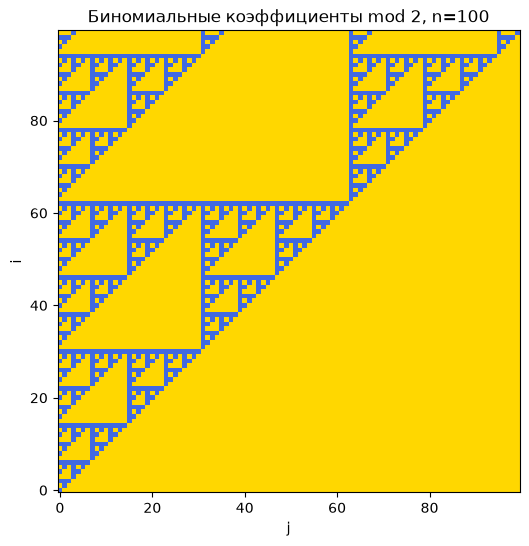

In [65]:
import math
n11 = 100
Pascal_mod2 = np.zeros((n11, n11), dtype=int)
for i in range(1, n11+1):
    for j in range(1, i+1):
        Pascal_mod2[i-1, j-1] = math.comb(i, j) % 2

plt.figure(figsize=(6,6))
plt.imshow(Pascal_mod2, cmap=ListedColormap(['gold','royalblue']))
plt.title(f"Биномиальные коэффициенты mod 2, n={n11}")
plt.xlabel("j"); plt.ylabel("i")
plt.gca().invert_yaxis()
plt.show()

Полученный узор — фрактал Серпинского, что является классическим следствием теоремы Куммера/Лукаса о чётности биномиальных коэффициентов.

## Задача 1.12

Матрица Адамара $H_n$: $H_nH_n^{T}=nI_n$, элементы $\pm1$, $H_0\equiv1$.

а) Выписать $H_1,H_2,H_4$; б) показать $H_4=H_2\otimes H_2$; в)$^*$ показать $H_{2^k}=H_2\otimes H_{2^{k-1}}$ (построение Сильвестра); г) изобразить $H_{2^6}$.

In [66]:
H1 = Matrix([[1]])
H2 = Matrix([[1,1],[1,-1]])
H4 = Matrix([[1,1,1,1],[1,-1,1,-1],[1,1,-1,-1],[1,-1,-1,1]])
print("H1 =", H1.tolist())
print("H2 =", H2.tolist())
print("H4 =", H4.tolist())
print("H1*H1.T == 1*I1 :", H1*H1.T == eye(1))
print("H2*H2.T == 2*I2 :", H2*H2.T == 2*eye(2))
print("H4*H4.T == 4*I4 :", H4*H4.T == 4*eye(4))

H1 = [[1]]
H2 = [[1, 1], [1, -1]]
H4 = [[1, 1, 1, 1], [1, -1, 1, -1], [1, 1, -1, -1], [1, -1, -1, 1]]
H1*H1.T == 1*I1 : True
H2*H2.T == 2*I2 : True
H4*H4.T == 4*I4 : True


In [67]:
from sympy.physics.quantum import TensorProduct
H2_kron_H2 = TensorProduct(H2, H2)
print("H2 (x) H2 == H4:", H2_kron_H2 == H4)
H2_kron_H2

H2 (x) H2 == H4: True


⎡1  1   1   1 ⎤
⎢             ⎥
⎢1  -1  1   -1⎥
⎢             ⎥
⎢1  1   -1  -1⎥
⎢             ⎥
⎣1  -1  -1  1 ⎦

**б)** Прямой проверкой $H_2\otimes H_2=H_4$ (напечатано выше — совпадает).

**в)** Индукция по $k$: положим $H_{2^k}:=H_2\otimes H_{2^{k-1}}$ (построение Сильвестра). Тогда, используя свойство произведения Кронекера $(A\otimes B)(C\otimes D)=(AC)\otimes(BD)$ и $(A\otimes B)^T=A^T\otimes B^T$:
$$H_{2^k}H_{2^k}^{T}=(H_2\otimes H_{2^{k-1}})(H_2^{T}\otimes H_{2^{k-1}}^{T})=(H_2H_2^{T})\otimes(H_{2^{k-1}}H_{2^{k-1}}^{T})=(2I_2)\otimes(2^{k-1}I_{2^{k-1}})=2^kI_{2^k}.$$
Это и есть требуемое свойство матрицы Адамара порядка $2^k$. Проверим численно для нескольких $k$:

In [68]:
def sylvester_hadamard(k):
    H = np.array([[1.0]])
    H2n = np.array([[1.0,1.0],[1.0,-1.0]])
    for _ in range(k):
        H = np.kron(H2n, H)
    return H

for k in range(1, 6):
    Hk = sylvester_hadamard(k)
    n_ = 2**k
    ok = np.allclose(Hk @ Hk.T, n_*np.eye(n_))
    print(f"k={k}, n={n_}: H_n H_n^T = n I_n  -> {ok}")

k=1, n=2: H_n H_n^T = n I_n  -> True
k=2, n=4: H_n H_n^T = n I_n  -> True
k=3, n=8: H_n H_n^T = n I_n  -> True
k=4, n=16: H_n H_n^T = n I_n  -> True
k=5, n=32: H_n H_n^T = n I_n  -> True


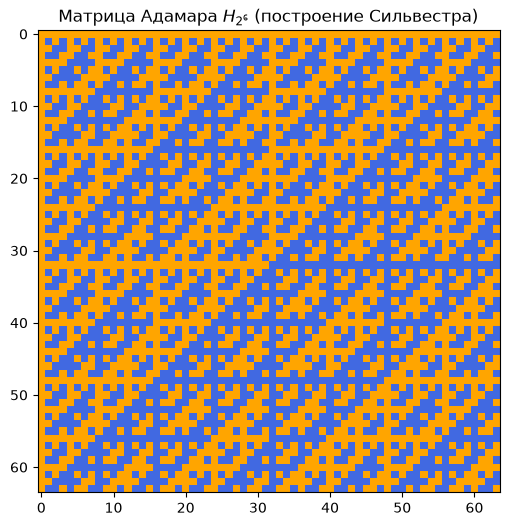

In [69]:
H64 = sylvester_hadamard(6)
plt.figure(figsize=(6,6))
plt.imshow(H64, cmap=ListedColormap(['royalblue','orange']))
plt.title("Матрица Адамара $H_{2^6}$ (построение Сильвестра)")
plt.show()

## Задача 1.13

$$A=\begin{pmatrix}14&10&21\\12&15&26\\18&11&27\end{pmatrix}.$$

$Z$ — собственное значение с наибольшей мнимой частью; $X=(1,U,V)$ — соответствующий собственный вектор.

In [70]:
A13 = np.array([[14,10,21],[12,15,26],[18,11,27]], dtype=float)
vals13, vecs13 = np.linalg.eig(A13)
idx = np.argmax(vals13.imag)
Z = vals13[idx]
v = vecs13[:, idx]
v_norm = v / v[0]
print("собственные значения:", vals13)
print("Z =", Z)
print("X = (1, U, V) =", v_norm)
print("Im(Z) =", Z.imag)
print("Re(U) =", v_norm[1].real)

собственные значения: [52.06231934+0.j          1.96884033+0.34478935j  1.96884033-0.34478935j]
Z = (1.968840330801648+0.34478934842718173j)
X = (1, U, V) = [ 1.        -1.73026019e-18j  3.74781973+1.33084677e+00j
 -2.35758843-6.17318019e-01j]
Im(Z) = 0.34478934842718173
Re(U) = 3.747819729394766


**Ответ:** 1) $\operatorname{Im}Z\approx 0{,}34479$; 2) $\operatorname{Re}U\approx 3{,}74782$.

## Задача 1.14

Найти минимальный многочлен матрицы $A$ (7×7, дана в условии).

In [71]:
A14 = Matrix([
[-3,7,-6,-1,8,-3,-2],
[1,-5,8,-3,-5,4,-5],
[1,3,-4,6,-2,0,8],
[-1,11,-12,9,3,-3,9],
[-3,11,-12,5,8,-4,6],
[-3,2,1,-4,4,1,-7],
[1,-5,6,-2,-4,3,-2]])
lam = symbols('lambda')
charpoly14 = A14.charpoly(lam)
print("характеристический многочлен:", charpoly14.as_expr())
print("разложение на множители:", factor(charpoly14.as_expr()))

характеристический многочлен: lambda**7 - 4*lambda**6 + 6*lambda**5 - 4*lambda**4 + lambda**3
разложение на множители: lambda**3*(lambda - 1)**4


$\chi_A(\lambda)=\lambda^3(\lambda-1)^4$. Минимальный многочлен делит характеристический и имеет те же корни $\{0,1\}$. Найдём кратности через ранги степеней $A$ и $A-I$ (наибольший жорданов блок для $\lambda_0$ = наименьшее $k$, при котором $\mathrm{rk}(A-\lambda_0 I)^k$ стабилизируется):

In [72]:
n14 = 7
I7 = eye(n14)
for k in range(1, 5):
    print(f"rank(A^{k}) =", (A14**k).rank())
print()
for k in range(1, 5):
    print(f"rank((A-I)^{k}) =", ((A14-I7)**k).rank())

rank(A^1) = 6
rank(A^2) = 5
rank(A^3) = 4
rank(A^4) = 4

rank((A-I)^1) = 5
rank((A-I)^2) = 3
rank((A-I)^3) = 3
rank((A-I)^4) = 3


In [73]:
# Прямой подбор наименьших степеней a,b: lambda^a (lambda-1)^b аннулирует A
found = None
for a in range(0, 4):
    for b in range(0, 5):
        if a == 0 and b == 0:
            continue
        M = (A14**a) * (A14-I7)**b
        if M == zeros(n14, n14):
            found = (a, b)
            break
    if found:
        break
print("минимальный многочлен: lambda^%d * (lambda-1)^%d" % found)
mu = expand(lam**found[0] * (lam-1)**found[1])
mu

минимальный многочлен: lambda^3 * (lambda-1)^2


**Ответ:** $\mu_A(\lambda)=\lambda^3(\lambda-1)^2=\lambda^5-2\lambda^4+\lambda^3$.

## Задача 1.15

Найти собственный ортонормированный базис и матрицу самосопряжённого оператора $\varphi$ в этом базисе, если

$$A_\varphi^{(e)}=\begin{pmatrix}17&-8&4\\-8&17&-4\\4&-4&11\end{pmatrix}.$$

In [74]:
A15 = Matrix([[17,-8,4],[-8,17,-4],[4,-4,11]])
eig15 = A15.eigenvects()
eig15

⎡⎛      ⎡⎡1⎤  ⎡-1/2⎤⎤⎞  ⎛       ⎡⎡2 ⎤⎤⎞⎤
⎢⎜      ⎢⎢ ⎥  ⎢    ⎥⎥⎟  ⎜       ⎢⎢  ⎥⎥⎟⎥
⎢⎜9, 2, ⎢⎢1⎥, ⎢ 0  ⎥⎥⎟, ⎜27, 1, ⎢⎢-2⎥⎥⎟⎥
⎢⎜      ⎢⎢ ⎥  ⎢    ⎥⎥⎟  ⎜       ⎢⎢  ⎥⎥⎟⎥
⎣⎝      ⎣⎣0⎦  ⎣ 1  ⎦⎦⎠  ⎝       ⎣⎣1 ⎦⎦⎠⎦

In [75]:
v1 = Matrix([1,1,0])
v2 = Matrix([-Rational(1,2),0,1])
v3 = Matrix([2,-2,1])
onb = GramSchmidt([v1,v2,v3], orthonormal=True)
Q15 = Matrix.hstack(*onb)
print("Ортонормированный базис (столбцы):")
Q15

Ортонормированный базис (столбцы):


⎡√2  -√2       ⎤
⎢──  ────  2/3 ⎥
⎢2    6        ⎥
⎢              ⎥
⎢√2   √2       ⎥
⎢──   ──   -2/3⎥
⎢2    6        ⎥
⎢              ⎥
⎢    2⋅√2      ⎥
⎢0   ────  1/3 ⎥
⎣     3        ⎦

In [76]:
D15 = simplify(Q15.T * A15 * Q15)
D15

⎡9  0  0 ⎤
⎢        ⎥
⎢0  9  0 ⎥
⎢        ⎥
⎣0  0  27⎦

**Ответ:** собственные значения $9,9,27$; ортонормированный базис
$$e_1'=\left(\tfrac{\sqrt2}{2},\tfrac{\sqrt2}{2},0\right),\ e_2'=\left(-\tfrac{\sqrt2}{6},\tfrac{\sqrt2}{6},\tfrac{2\sqrt2}{3}\right),\ e_3'=\left(\tfrac23,-\tfrac23,\tfrac13\right),$$
матрица оператора в этом базисе — $\mathrm{diag}(9,9,27)$.

## Задача 1.16

Найти ортогональное преобразование, приводящее к главным осям квадратичную функцию
$$f(x_1,x_2,x_3,x_4)=3x_1^2+8x_1x_2-3x_2^2+4x_3^2-4x_3x_4+x_4^2.$$

In [77]:
A16 = Matrix([[3,4,0,0],[4,-3,0,0],[0,0,4,-2],[0,0,-2,1]])
eig16 = A16.eigenvects()
eig16

⎡⎛       ⎡⎡-1/2⎤⎤⎞  ⎛      ⎡⎡ 0 ⎤⎤⎞  ⎛      ⎡⎡2⎤  ⎡0 ⎤⎤⎞⎤
⎢⎜       ⎢⎢    ⎥⎥⎟  ⎜      ⎢⎢   ⎥⎥⎟  ⎜      ⎢⎢ ⎥  ⎢  ⎥⎥⎟⎥
⎢⎜       ⎢⎢ 1  ⎥⎥⎟  ⎜      ⎢⎢ 0 ⎥⎥⎟  ⎜      ⎢⎢1⎥  ⎢0 ⎥⎥⎟⎥
⎢⎜-5, 1, ⎢⎢    ⎥⎥⎟, ⎜0, 1, ⎢⎢   ⎥⎥⎟, ⎜5, 2, ⎢⎢ ⎥, ⎢  ⎥⎥⎟⎥
⎢⎜       ⎢⎢ 0  ⎥⎥⎟  ⎜      ⎢⎢1/2⎥⎥⎟  ⎜      ⎢⎢0⎥  ⎢-2⎥⎥⎟⎥
⎢⎜       ⎢⎢    ⎥⎥⎟  ⎜      ⎢⎢   ⎥⎥⎟  ⎜      ⎢⎢ ⎥  ⎢  ⎥⎥⎟⎥
⎣⎝       ⎣⎣ 0  ⎦⎦⎠  ⎝      ⎣⎣ 1 ⎦⎦⎠  ⎝      ⎣⎣0⎦  ⎣1 ⎦⎦⎠⎦

In [78]:
vecs16 = []
vals16 = []
for val, mult, vs in eig16:
    for v in vs:
        vecs16.append(v.normalized())
        vals16.append(val)
Q16 = Matrix.hstack(*vecs16)
print("собственные значения (в порядке столбцов Q):", vals16)
print("ортогональность Q^T Q = I:", simplify(Q16.T*Q16) == eye(4))
Q16

собственные значения (в порядке столбцов Q): [-5, 0, 5, 5]
ортогональность Q^T Q = I: True


⎡-√5         2⋅√5        ⎤
⎢────   0    ────    0   ⎥
⎢ 5           5          ⎥
⎢                        ⎥
⎢2⋅√5         √5         ⎥
⎢────   0     ──     0   ⎥
⎢ 5           5          ⎥
⎢                        ⎥
⎢       √5         -2⋅√5 ⎥
⎢ 0     ──    0    ──────⎥
⎢       5            5   ⎥
⎢                        ⎥
⎢      2⋅√5          √5  ⎥
⎢ 0    ────   0      ──  ⎥
⎣       5            5   ⎦

In [79]:
canonical16 = simplify(Q16.T * A16 * Q16)
canonical16

⎡-5  0  0  0⎤
⎢           ⎥
⎢0   0  0  0⎥
⎢           ⎥
⎢0   0  5  0⎥
⎢           ⎥
⎣0   0  0  5⎦

**Ответ:** при ортогональном преобразовании $x=Qy$ с $Q$, указанной выше (столбцы — нормированные собственные векторы), квадратичная форма принимает канонический вид
$$f=-5y_1^2+5y_3^2+5y_4^2\quad(\text{коэффициент при }y_2\text{ равен }0).$$

## Задача 1.17

Определить тип кривой второго порядка, канонический вид и каноническую систему координат:

a) $5x^2+4xy+8y^2-32x-56y+80=0$;
b) $5x^2+12xy-22x-12y-19=0$.

Общая схема: матрица квадратичной части $M=\begin{pmatrix}A&B\\B&C\end{pmatrix}$ (для $Ax^2+2Bxy+Cy^2+2Dx+2Ey+F$), поворот по собственным векторам $M$ убирает $xy$-член, затем сдвиг (выделение полного квадрата) убирает линейные члены.

In [80]:
def classify_conic(A_, B_, C_, D_, E_, F_):
    A_,B_,C_,D_,E_,F_ = map(nsimplify, (A_,B_,C_,D_,E_,F_))
    M = Matrix([[A_,B_],[B_,C_]])
    pairs = []
    for val, mult, vs in M.eigenvects():
        for v in vs:
            pairs.append((val, v.normalized()))
    Q = Matrix.hstack(*[p[1] for p in pairs])
    if Q.det() == -1:
        pairs = [pairs[1], pairs[0]]
        Q = Matrix.hstack(*[p[1] for p in pairs])
    l1, l2 = pairs[0][0], pairs[1][0]
    lin = Matrix([[D_, E_]]) * Q
    Dp, Ep = lin[0], lin[1]
    x0, y0 = symbols('x0 y0')
    xr, yr = symbols('xr yr')
    expr = l1*xr**2 + l2*yr**2 + 2*Dp*xr + 2*Ep*yr + F_
    # translation
    if l1 != 0:
        expr = expand(expr.subs(xr, x0 - Dp/l1))
    if l2 != 0:
        expr = expand(expr.subs(yr, y0 - Ep/l2))
    center = solve([2*A_*symbols('x')+2*B_*symbols('y')+2*D_,
                    2*B_*symbols('x')+2*C_*symbols('y')+2*E_], symbols('x y'))
    theta_deg = (atan2(Q[1,0], Q[0,0]) * 180 / pi).evalf()
    return M, Q, (l1,l2), expr, center, theta_deg

M_a, Q_a, lam_a, eq_a, center_a, theta_a = classify_conic(5,2,8,-16,-28,80)
print("Матрица M =", M_a.tolist())
print("Собственные числа:", lam_a)
print("Матрица поворота Q =", Q_a.tolist())
print("Центр (x0,y0) =", center_a)
print("Угол поворота, град =", theta_a)
print("Уравнение в канонической системе:", eq_a, "= 0")

Матрица M = [[5, 2], [2, 8]]
Собственные числа: (9, 4)
Матрица поворота Q = [[sqrt(5)/5, -2*sqrt(5)/5], [2*sqrt(5)/5, sqrt(5)/5]]
Центр (x0,y0) = {x: 2, y: 3}
Угол поворота, град = 63.4349488229220
Уравнение в канонической системе: 9*x0**2 + 4*y0**2 - 36 = 0


$9x_0^2+4y_0^2-36=0\ \Rightarrow\ \dfrac{x_0^2}{4}+\dfrac{y_0^2}{9}=1$ — **эллипс** с центром $(2,3)$ и углом поворота осей $\theta=\arctan2\approx63{,}43^\circ$.

In [81]:
M_b, Q_b, lam_b, eq_b, center_b, theta_b = classify_conic(5,6,0,-11,-6,-19)
print("Матрица M =", M_b.tolist())
print("Собственные числа:", lam_b)
print("Матрица поворота Q =", Q_b.tolist())
print("Центр (x0,y0) =", center_b)
print("Угол поворота, град =", theta_b)
print("Уравнение в канонической системе:", eq_b, "= 0")

Матрица M = [[5, 6], [6, 0]]
Собственные числа: (9, -4)
Матрица поворота Q = [[3*sqrt(13)/13, -2*sqrt(13)/13], [2*sqrt(13)/13, 3*sqrt(13)/13]]
Центр (x0,y0) = {x: 1, y: 1}
Угол поворота, град = 33.6900675259798
Уравнение в канонической системе: 9*x0**2 - 4*y0**2 - 36 = 0


$9x_0^2-4y_0^2-36=0\ \Rightarrow\ \dfrac{x_0^2}{4}-\dfrac{y_0^2}{9}=1$ — **гипербола** с центром $(1,1)$ и углом поворота осей $\theta=\arctan(2/3)\approx33{,}69^\circ$.

**Ответ:** a) эллипс $\dfrac{x_0^2}{4}+\dfrac{y_0^2}{9}=1$; b) гипербола $\dfrac{x_0^2}{4}-\dfrac{y_0^2}{9}=1$.

## Задача 1.18

При каких $\lambda$ форма $Q(x_1,x_2,x_3)=x_1^2+4x_2^2+x_3^2+2\lambda x_1x_2+10x_1x_3+6x_2x_3$ положительно определена?

По критерию Сильвестра нужно $M_1>0,\ M_2>0,\ M_3>0$ для угловых миноров матрицы $A=\begin{pmatrix}1&\lambda&5\\\lambda&4&3\\5&3&1\end{pmatrix}$.

In [82]:
lam18 = symbols('lambda', real=True)
A18 = Matrix([[1,lam18,5],[lam18,4,3],[5,3,1]])
M1_18 = A18[0,0]
M2_18 = expand(A18[:2,:2].det())
M3_18 = expand(A18.det())
print("M1 =", M1_18)
print("M2 =", M2_18)
print("M3 =", M3_18)

sol_M2 = solve_univariate_inequality(M2_18 > 0, lam18, relational=False)
sol_M3 = solve_univariate_inequality(M3_18 > 0, lam18, relational=False)
print("M2>0 при lambda in", sol_M2)
print("M3>0 при lambda in", sol_M3)
print("Пересечение:", Intersection(sol_M2, sol_M3))

M1 = 1
M2 = 4 - lambda**2
M3 = -lambda**2 + 30*lambda - 105
M2>0 при lambda in Interval.open(-2, 2)
M3>0 при lambda in Interval.open(15 - 2*sqrt(30), 2*sqrt(30) + 15)
Пересечение: EmptySet


In [83]:
# Численная проверка: перебираем lambda и смотрим на собственные значения A(lambda)
import numpy as np
found_any = False
for lam_val in np.linspace(-50, 50, 4001):
    Anum = np.array([[1, lam_val, 5], [lam_val, 4, 3], [5, 3, 1]])
    if np.all(np.linalg.eigvalsh(Anum) > 0):
        found_any = True
        break
print("Существует ли lambda, при котором Q положительно определена?", found_any)

Существует ли lambda, при котором Q положительно определена? False


Условие $M_2>0$ даёт $\lambda\in(-2,2)$, а условие $M_3>0$ даёт $\lambda\in(15-2\sqrt{30},\,15+2\sqrt{30})\approx(4{,}05;\,25{,}95)$. Эти интервалы не пересекаются.

**Ответ:** таких $\lambda$ не существует — форма $Q$ не является положительно определённой ни при каком значении параметра $\lambda$.

## Задача 1.19

При каких $\lambda$ форма $Q(x_1,x_2,x_3)=\lambda x_1^2-2x_2^2-3x_3^2+2x_1x_2-2x_1x_3+2x_2x_3$ отрицательно определена?

Критерий Сильвестра для отрицательной определённости: знаки угловых миноров чередуются, начиная с минуса: $N_1<0,\ N_2>0,\ N_3<0$.

In [84]:
lam19 = symbols('lambda', real=True)
A19 = Matrix([[lam19,1,-1],[1,-2,1],[-1,1,-3]])
N1 = A19[0,0]
N2 = expand(A19[:2,:2].det())
N3 = expand(A19.det())
print("N1 =", N1, " N2 =", N2, " N3 =", N3)

c1 = solve_univariate_inequality(N1 < 0, lam19, relational=False)
c2 = solve_univariate_inequality(N2 > 0, lam19, relational=False)
c3 = solve_univariate_inequality(N3 < 0, lam19, relational=False)
print("N1<0:", c1)
print("N2>0:", c2)
print("N3<0:", c3)
final19 = Intersection(c1, c2, c3)
print("Итоговое условие:", final19)

N1 = lambda  N2 = -2*lambda - 1  N3 = 5*lambda + 3
N1<0: Interval.open(-oo, 0)
N2>0: Interval.open(-oo, -1/2)
N3<0: Interval.open(-oo, -3/5)
Итоговое условие: Interval.open(-oo, -3/5)


**Ответ:** $\lambda<-\dfrac35$.

## Задача 1.20

Эквивалентны ли над $\mathbb R$ квадратичные формы
$$Q_1=2x_1^2+9x_2^2+3x_3^2+8x_1x_2-4x_1x_3-10x_2x_3,\qquad Q_2=2x_1^2+3x_2^2+6x_3^2-4x_1x_2-4x_1x_3+8x_2x_3\,?$$

*(В условии первое слагаемое $Q_2$ напечатано как $2x_1$ — очевидная опечатка, читаем как $2x_1^2$, иначе выражение не является квадратичной формой.)*

По закону инерции Сильвестра две квадратичные формы эквивалентны над $\mathbb R$ тогда и только тогда, когда у них одинаковый ранг и одинаковая сигнатура (число положительных и отрицательных собственных значений соответствующей симметричной матрицы).

In [85]:
Q1 = Matrix([[2,4,-2],[4,9,-5],[-2,-5,3]])
Q2 = Matrix([[2,-2,-2],[-2,3,4],[-2,4,6]])

e1 = [complex(v) for v in Matrix(Q1).eigenvals(multiple=True)]
e2 = [complex(v) for v in Matrix(Q2).eigenvals(multiple=True)]

def signature(vals, tol=1e-9):
    pos = sum(1 for v in vals if v.real > tol)
    neg = sum(1 for v in vals if v.real < -tol)
    zero = len(vals) - pos - neg
    return pos, neg, zero

print("Собственные значения Q1:", e1, " сигнатура (+, -, 0):", signature(e1))
print("Собственные значения Q2:", e2, " сигнатура (+, -, 0):", signature(e2))
print("rank Q1 =", Q1.rank(), " rank Q2 =", Q2.rank())

Собственные значения Q1: [0j, (13.557438524302+0j), (0.44256147569799936+0j)]  сигнатура (+, -, 0): (2, 0, 1)
Собственные значения Q2: [0j, (1.2279981273412344+0j), (9.772001872658766+0j)]  сигнатура (+, -, 0): (2, 0, 1)
rank Q1 = 2  rank Q2 = 2


Обе формы имеют ранг $2$ и сигнатуру $(2,0,1)$ — два положительных собственных значения и одно нулевое.

**Ответ:** да, $Q_1$ и $Q_2$ эквивалентны над $\mathbb R$ (совпадают ранг и сигнатура — закон инерции Сильвестра).